<a href="https://colab.research.google.com/github/WuDianQiBian/ml-course/blob/master/notebooks/ch02_python_basics/sec08_numpy_5_answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NumPy 5 思考题

<p align="center">
  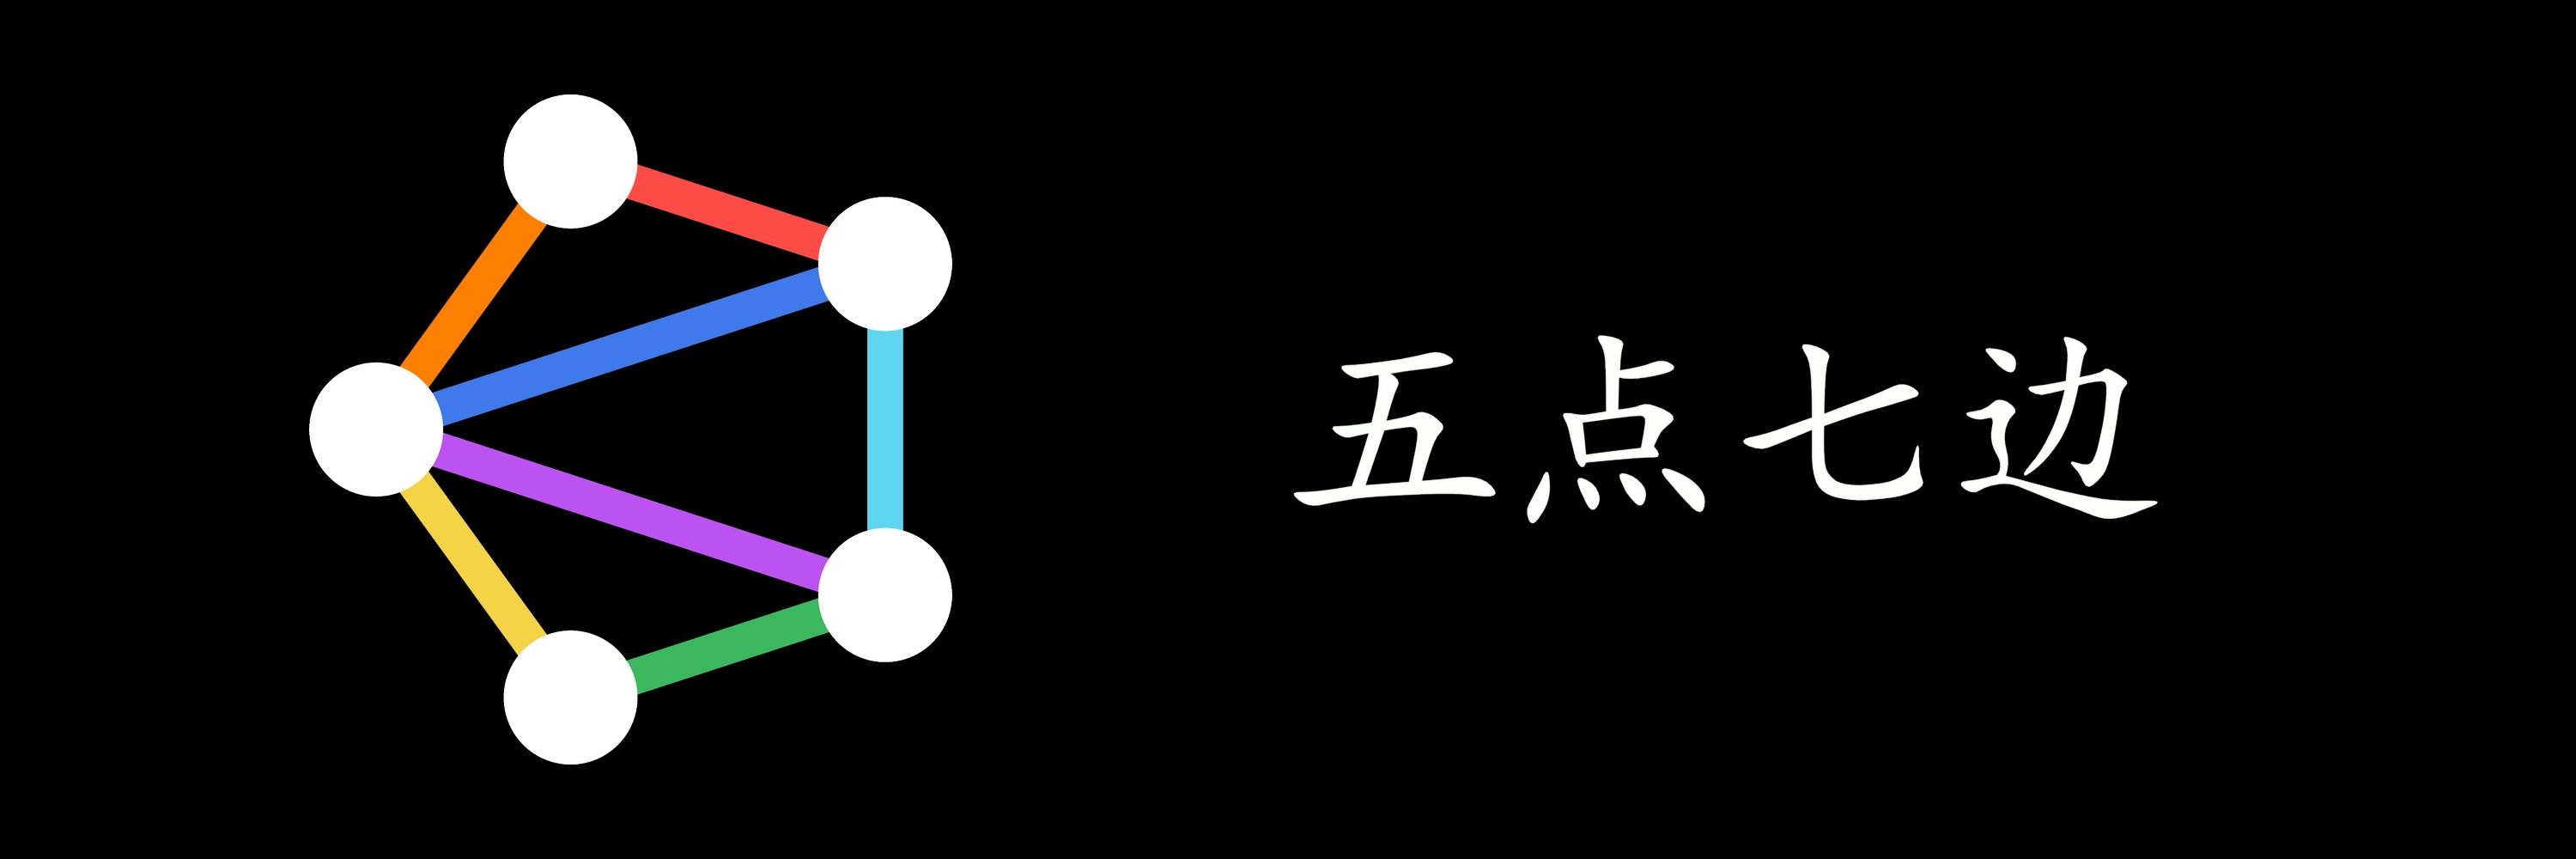
</p>


## 思考题

In [1]:
def softmax(X):
    exp_X = np.exp(X)
    sum_X = np.sum(exp_X, axis=-1, keepdims=True)
    return exp_X / sum_X

<p>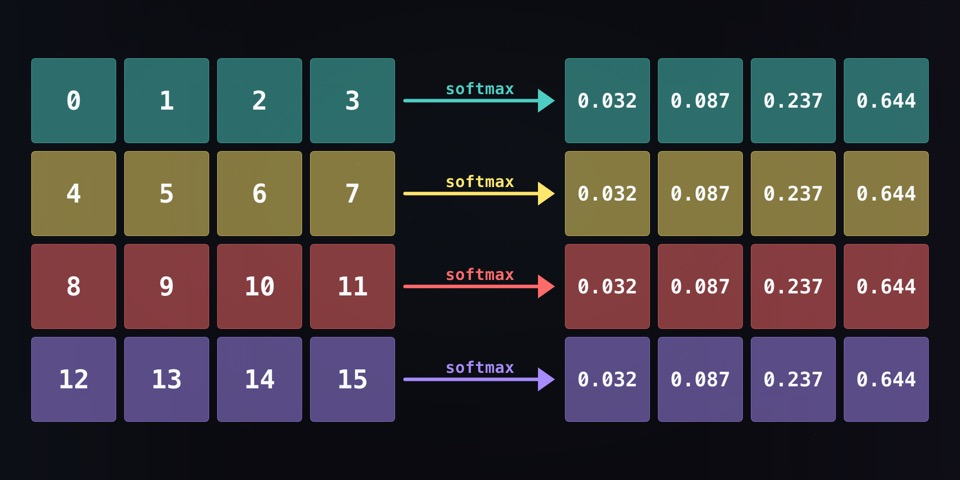</p>

**问题:** 如何实现masked softmax?

<p>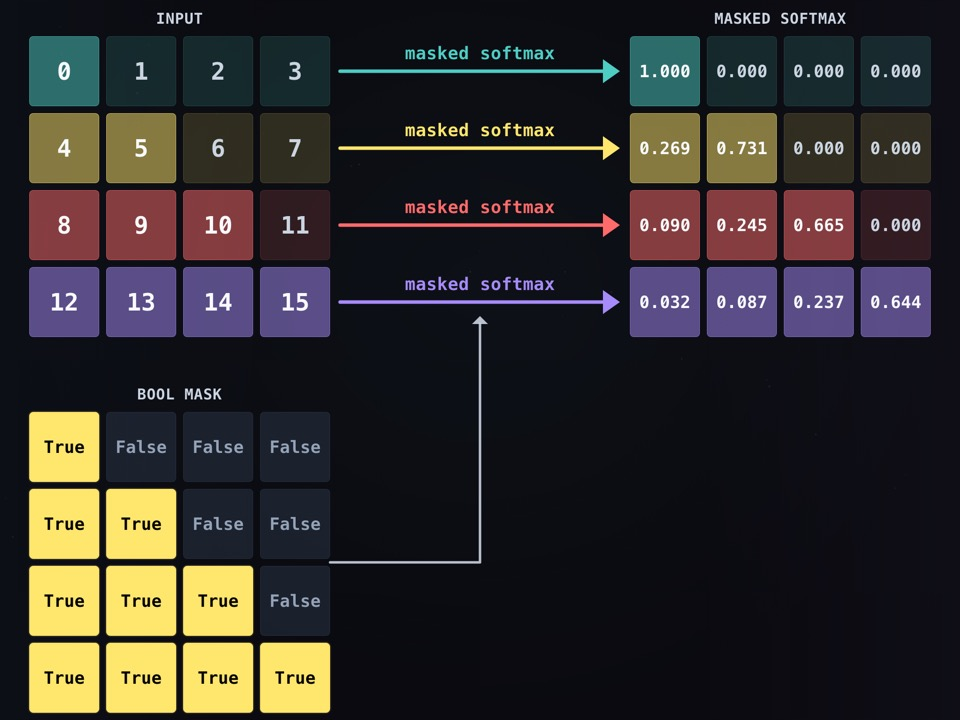</p>

**提示:**
- 这个下三角 `mask` 可以用 `np.tri()` 函数生成
- 是否可以不用循环呢?

# 答案

In [2]:
import numpy as np

# 测试数据
X = np.arange(16, dtype=np.float64).reshape(4, 4)
mask = np.tri(4, dtype=bool)

print("X:")
print(X)
print()
print("mask:")
print(mask)

X:
[[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]
 [12. 13. 14. 15.]]

mask:
[[ True False False False]
 [ True  True False False]
 [ True  True  True False]
 [ True  True  True  True]]


## 方法一：循环版本

In [3]:
def masked_softmax_loop(X, mask):
    result = np.zeros_like(X)
    for i in range(X.shape[0]):
        row_mask = mask[i]
        result[i, row_mask] = softmax(X[i, row_mask])
    return result

result_loop = masked_softmax_loop(X, mask)
print("循环版本:")
print(result_loop)

循环版本:
[[1.         0.         0.         0.        ]
 [0.26894142 0.73105858 0.         0.        ]
 [0.09003057 0.24472847 0.66524096 0.        ]
 [0.0320586  0.08714432 0.23688282 0.64391426]]


## 方法二：批处理版本
回顾 Softmax 定义：

$$
\mathrm{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}
$$

关键性质：

$$e^{-\infty} = 0$$

下面演示 masked softmax 的逐步计算过程：

<table>
<tr><td><b>步骤</b></td><td><b>数值</b></td></tr>
<tr><td>原数组</td><td><code>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;4&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;5&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;6&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;7</code></td></tr>
<tr><td>mask</td><td><code>&nbsp;&nbsp;True&nbsp;&nbsp;&nbsp;&nbsp;True&nbsp;&nbsp;&nbsp;False&nbsp;&nbsp;&nbsp;False</code></td></tr>
<tr><td>填入 −∞</td><td><code>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;4&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;5&nbsp;&nbsp;&nbsp;&nbsp;-inf&nbsp;&nbsp;&nbsp;&nbsp;-inf</code></td></tr>
<tr><td>e<sup>x<sub>i</sub></sup></td><td><code>&nbsp;54.60&nbsp;&nbsp;148.41&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;0&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;0</code></td></tr>
<tr><td>Softmax(x<sub>i</sub>)</td><td><code>&nbsp;&nbsp;0.27&nbsp;&nbsp;&nbsp;&nbsp;0.73&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;0&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;0</code></td></tr>
</table>

> 解释: 被 mask 遮住的位置填入 $-\infty$，经过 $e^{-\infty}=0$ 后自然不参与求和，最终 Softmax 只在有效位置上分配概率。

In [4]:
def masked_softmax(X, mask):
    X = X.copy()
    X[~mask] = -np.inf              # exp(-inf) = 0，不参与求和
    return softmax(X)

result = masked_softmax(X, mask)
print("批处理版本:")
print(result)

批处理版本:
[[1.         0.         0.         0.        ]
 [0.26894142 0.73105858 0.         0.        ]
 [0.09003057 0.24472847 0.66524096 0.        ]
 [0.0320586  0.08714432 0.23688282 0.64391426]]
